# DSBA6010 Final Project
## LLM-Based Privacy Attacks on Employee Attrition Data

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)  
**Project Overview:**  
This notebook investigates the privacy risks of sharing employee data in the age of Large Language Models (LLMs). We:
1. Load and explore the IBM HR Analytics dataset
2. Predict employee **Attrition** (Yes/No)
3. Apply Differential Privacy (DP) at multiple epsilon levels
4. Assess utility (model accuracy) after privatization
5. Attack the privatized dataset using Membership Inference and Attribute Inference attacks

**References:**
- Liu et al. (2025) — Evaluating LLM-based Personal Information Extraction and Countermeasures. USENIX Security.
- Staab et al. (2024) — Beyond Memorization: Violating Privacy via Inference with LLMs. ICLR.
- Jayaraman & Evans (2022) — Are Attribute Inference Attacks Just Imputation? CCS.
- Kandpal et al. (2024) — User Inference Attacks on Large Language Models. EMNLP.
- Cirillo et al. (2025) — Augmenting Anonymized Data with AI. arXiv.
- Yan et al. (2025) — Stop Tracking Me! Proactive Defense Against Attribute Inference Attacks. arXiv.

## 0. Install Dependencies

In [1]:
# Run this cell once to install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn diffprivlib kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 9.9 MB/s eta 0:00:00


## 1. Setup & Data Loading

**Option A:** Download via Kaggle API (recommended)  
**Option B:** Manual download — go to the [Kaggle page](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset), download `WA_Fn-UseC_-HR-Employee-Attrition.csv`, and place it in the same folder as this notebook.

In [72]:
# Direct download from URL
import pandas as pd

# Direct URL to the dataset (hosted on GitHub)
URL = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"

# Alternative URL if the above doesn't work:
# URL = "https://raw.githubusercontent.com/abulbasar/data/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"

print("Loading dataset from URL...")
df = pd.read_csv(URL)
print(f"Dataset loaded successfully! Shape: {df.shape}")

Loading dataset from URL...
Dataset loaded successfully! Shape: (1470, 35)


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(list(df.columns))

Dataset shape: (1470, 35)

Columns (35):
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 2. Exploratory Data Analysis (EDA)

In [9]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [46]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

Missing values per column:
None — dataset is complete.


In [74]:
# Explore key variables in the dataset
print("Key dataset statistics:")
print(f"Total employees: {len(df)}")
print(f"\nAttrition distribution:")
print(df['Attrition'].value_counts())
print(f"Attrition rate: {(df['Attrition'] == 'Yes').mean():.1%}")
print(f"\nDepartments: {df['Department'].nunique()}")
print(df['Department'].value_counts())
print(f"\nGender distribution:")
print(df['Gender'].value_counts())
print(f"\nAge range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Average age: {df['Age'].mean():.1f} years")

Key dataset statistics:
Total employees: 1470

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1%

Departments: 3
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Gender distribution:
Gender
Male      882
Female    588
Name: count, dtype: int64

Age range: 18 - 60 years
Average age: 36.9 years


In [75]:
# Explore Attrition values
print("Attrition value counts:")
print(df['Attrition'].value_counts())
attrition_counts = df['Attrition'].value_counts()
print(f"\nAttrition rate: {(df['Attrition'] == 'Yes').sum()} employees ({(df['Attrition'] == 'Yes').mean():.1%})")
print(f"Retention rate: {(df['Attrition'] == 'No').sum()} employees ({(df['Attrition'] == 'No').mean():.1%})")
print(f"\nTotal records: {len(df)}")

Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 237 employees (16.1%)
Retention rate: 1233 employees (83.9%)

Total records: 1470


### 📊 Attrition Overview

**Target Variable: Attrition (Yes/No)**
- **Attrition = Yes**: Employee left the company
- **Attrition = No**: Employee stayed with the company

**Key Characteristics:**
1. **Binary classification**: Predict whether an employee will leave (Yes) or stay (No)
2. **Class balance**: Typical HR datasets show imbalanced classes (more retention than attrition)
3. **Business impact**: High attrition costs companies time and money in recruitment and training

**For this analysis:**
- We predict **Attrition** as our target variable
- All available features will be used for prediction
- This binary classification is ideal for demonstrating privacy attack risks

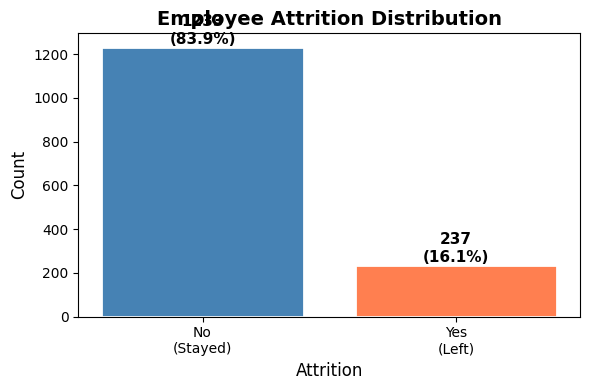

In [76]:
# Visualize Attrition distribution
attrition_counts = df['Attrition'].value_counts()
labels = ['No\n(Stayed)', 'Yes\n(Left)']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, attrition_counts.values, color=['steelblue', 'coral'], edgecolor='white', linewidth=2)
ax.set_title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Attrition', fontsize=12)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df):.1%})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

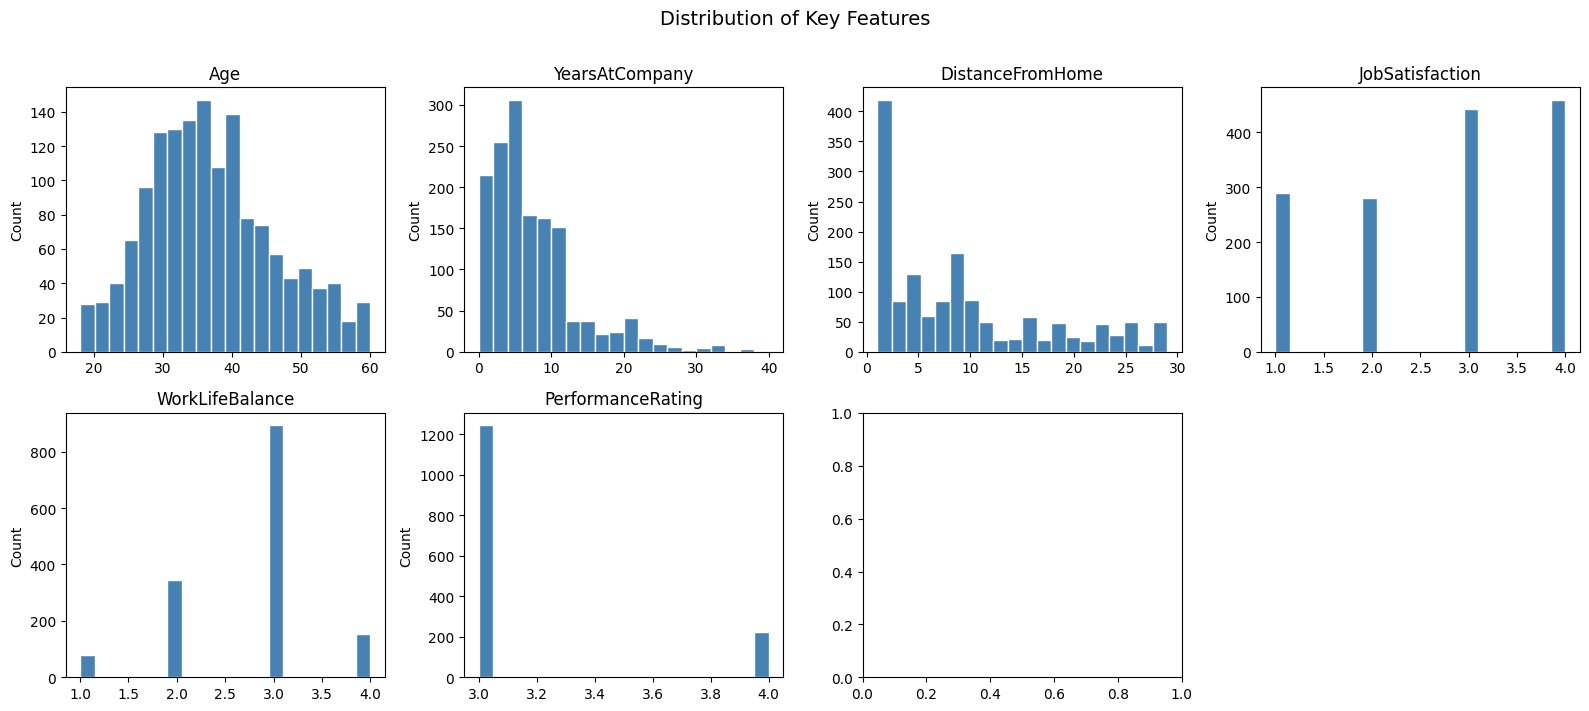

In [51]:
# Distribution of key numeric features
numeric_cols = ['Age', 'YearsAtCompany', 'DistanceFromHome',
                'JobSatisfaction', 'WorkLifeBalance', 'PerformanceRating']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Distribution of Key Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

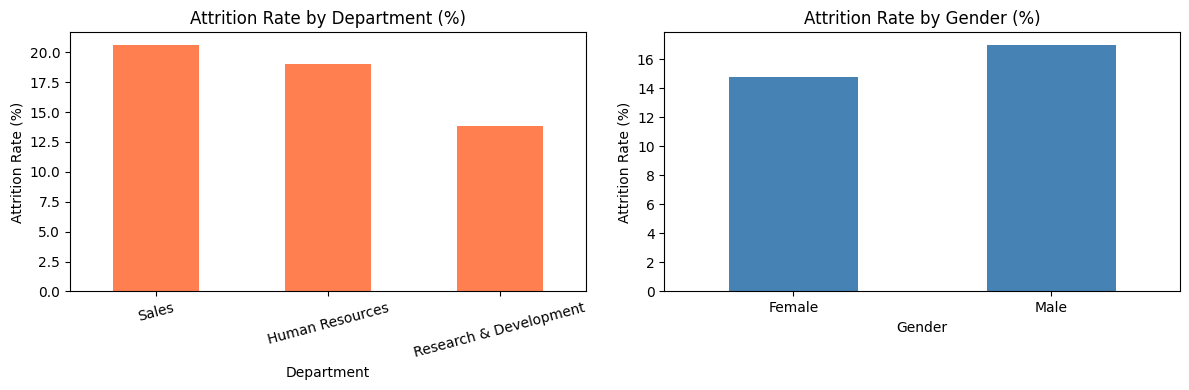

In [77]:
# Attrition Rate by Department and Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)
dept_attrition.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Attrition Rate by Department (%)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# Attrition rate by Gender
gender_attrition = df.groupby('Gender')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
gender_attrition.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Attrition Rate by Gender (%)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

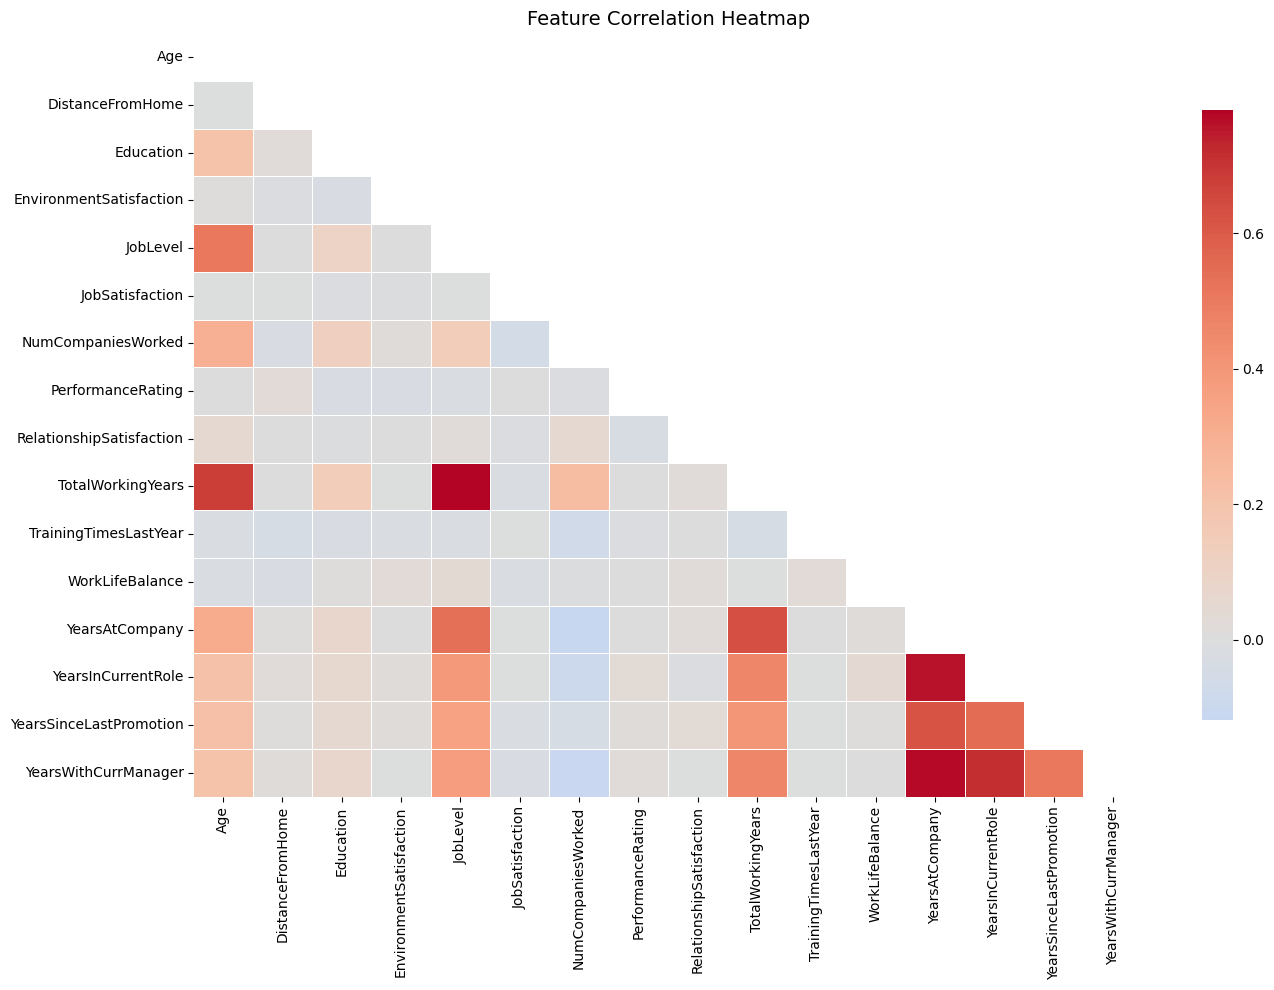

In [53]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Create the **Attrition** target variable (binary: 1 = Yes, 0 = No).  
Remove constant columns and employee identifiers.  
Encode categorical variables and split into train/test sets.  
This preprocessed dataset will serve as the **baseline** before any privatization.

In [78]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_processed = df.copy()

# Encode Attrition target variable (1 = Yes, 0 = No)
df_processed['Attrition'] = (df_processed['Attrition'] == 'Yes').astype(int)
print("Encoded target variable: Attrition")
print(f"Attrition (Left): {df_processed['Attrition'].sum()} ({df_processed['Attrition'].mean():.1%})")
print(f"No Attrition (Stayed): {(df_processed['Attrition']==0).sum()} ({(df_processed['Attrition']==0).mean():.1%})")

# Drop constant columns and identifiers
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
drop_cols = [col for col in drop_cols if col in df_processed.columns]
if drop_cols:
    df_processed = df_processed.drop(columns=drop_cols)
    print(f"\nDropped constant/ID columns: {drop_cols}")

# Encode binary/categorical columns
le = LabelEncoder()
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()
print(f"\nEncoding categorical columns: {categorical_cols}")

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Features and target
X = df_processed.drop(columns=['Attrition'])
y = df_processed['Attrition']  # 0 = No Attrition (Stayed), 1 = Attrition (Left)

# Train/test split (stratified to preserve Attrition ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Attrition rate (train): {y_train.mean():.1%}")

Encoded target variable: Attrition
Attrition (Left): 237 (16.1%)
No Attrition (Stayed): 1233 (83.9%)

Dropped constant/ID columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

Encoding categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Train size: 1176 | Test size: 294
Features: 30
Attrition rate (train): 16.2%


## 3.5 Multicollinearity Assessment (VIF)

**Variance Inflation Factor (VIF)** measures how much the variance of a regression coefficient is inflated due to multicollinearity with other predictors.

**Interpretation:**
- **VIF = 1**: No correlation with other features
- **VIF < 5**: Acceptable level of multicollinearity
- **VIF 5-10**: Moderate multicollinearity (monitor)
- **VIF > 10**: High multicollinearity (consider removal or dimensionality reduction)

In [79]:
# Calculate VIF for all features
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the scaled training data for VIF calculation
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_df.values, i) 
                   for i in range(len(X_train.columns))]

# Sort by VIF value (descending)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("="*70)
print("Variance Inflation Factor (VIF) Analysis")
print("="*70)
print(vif_data.to_string(index=False))
print("="*70)

# Identify features with high VIF
high_vif = vif_data[vif_data['VIF'] > 10]
moderate_vif = vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)]
low_vif = vif_data[vif_data['VIF'] < 5]

print(f"\n📊 VIF Summary:")
print(f"   High multicollinearity (VIF > 10): {len(high_vif)} features")
print(f"   Moderate multicollinearity (5 ≤ VIF ≤ 10): {len(moderate_vif)} features")
print(f"   Low multicollinearity (VIF < 5): {len(low_vif)} features")

if len(high_vif) > 0:
    print(f"\n⚠️  Features with high VIF (>10):")
    for idx, row in high_vif.iterrows():
        print(f"   - {row['Feature']}: {row['VIF']:.2f}")
else:
    print(f"\n✓ No features with severe multicollinearity (all VIF < 10)")

Variance Inflation Factor (VIF) Analysis
                 Feature       VIF
                JobLevel 11.358882
           MonthlyIncome 10.481648
       TotalWorkingYears  4.952089
          YearsAtCompany  4.619871
    YearsWithCurrManager  2.877965
      YearsInCurrentRole  2.613574
       PerformanceRating  2.532087
       PercentSalaryHike  2.528841
                     Age  2.150032
              Department  2.015743
                 JobRole  1.940036
           MaritalStatus  1.818708
        StockOptionLevel  1.813024
 YearsSinceLastPromotion  1.646910
      NumCompaniesWorked  1.272181
               Education  1.065300
                OverTime  1.037243
RelationshipSatisfaction  1.032158
          JobInvolvement  1.030466
          BusinessTravel  1.029382
                  Gender  1.029100
   TrainingTimesLastYear  1.026672
             MonthlyRate  1.026487
              HourlyRate  1.026293
         JobSatisfaction  1.024627
 EnvironmentSatisfaction  1.024556
         WorkL

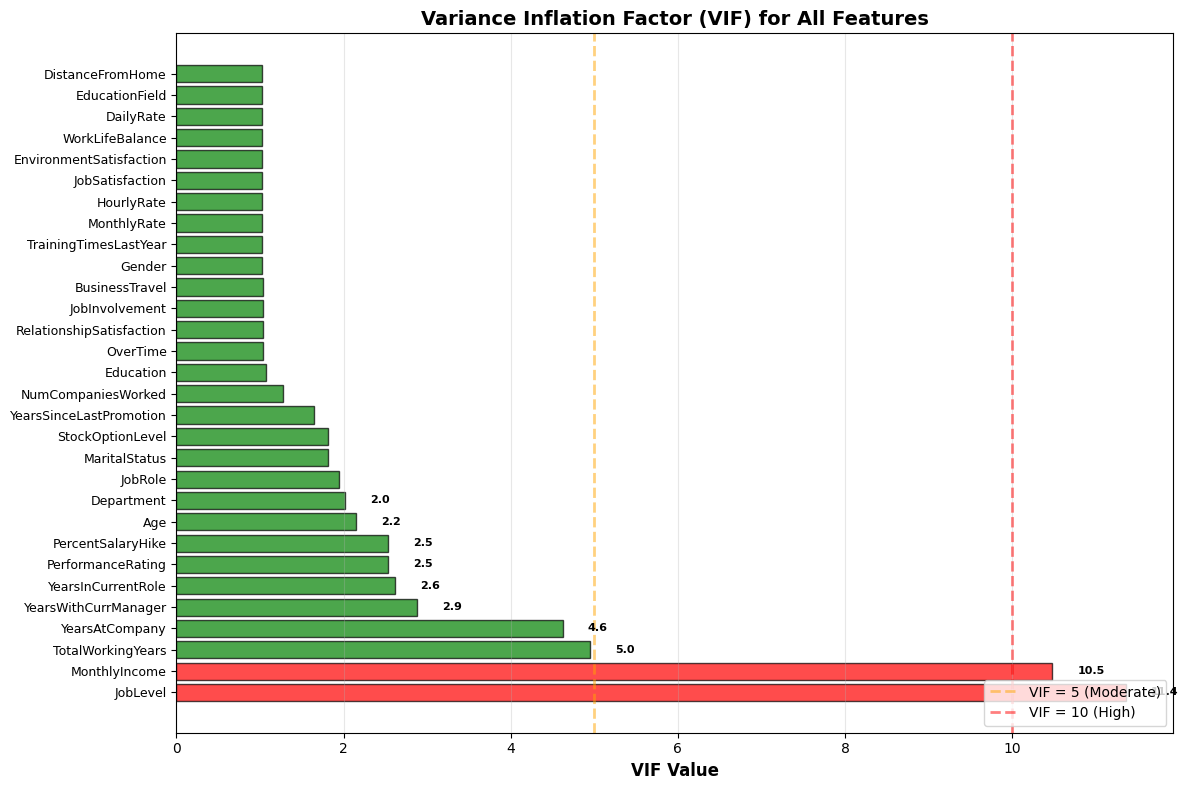


💡 Insights:
   - Features with VIF > 10 indicate strong linear relationships with other features
   - Regularization (L1/L2/ElasticNet) can help mitigate multicollinearity effects
   - L1 (Lasso) regularization performs automatic feature selection


In [80]:
# Visualize VIF values
fig, ax = plt.subplots(figsize=(12, 8))

# Color code by severity
colors = ['red' if vif > 10 else 'orange' if vif >= 5 else 'green' 
          for vif in vif_data['VIF']]

# Horizontal bar chart
bars = ax.barh(range(len(vif_data)), vif_data['VIF'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(vif_data)))
ax.set_yticklabels(vif_data['Feature'], fontsize=9)
ax.set_xlabel('VIF Value', fontsize=12, fontweight='bold')
ax.set_title('Variance Inflation Factor (VIF) for All Features', fontsize=14, fontweight='bold')

# Add reference lines
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='VIF = 5 (Moderate)')
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='VIF = 10 (High)')

# Add value labels on bars
for i, (bar, vif) in enumerate(zip(bars, vif_data['VIF'])):
    if vif > 2:  # Only show labels for VIF > 2 to avoid clutter
        ax.text(vif + 0.3, i, f'{vif:.1f}', va='center', fontsize=8, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Additional insights
print("\n💡 Insights:")
print("   - Features with VIF > 10 indicate strong linear relationships with other features")
print("   - Regularization (L1/L2/ElasticNet) can help mitigate multicollinearity effects")
print("   - L1 (Lasso) regularization performs automatic feature selection")


🔍 Examining correlation between high VIF features:

Correlation Matrix for High VIF and Related Features:
                   MonthlyIncome  JobLevel    Age  YearsAtCompany  \
MonthlyIncome              1.000     0.947  0.511           0.505   
JobLevel                   0.947     1.000  0.526           0.527   
Age                        0.511     0.526  1.000           0.313   
YearsAtCompany             0.505     0.527  0.313           1.000   
TotalWorkingYears          0.775     0.785  0.695           0.618   

                   TotalWorkingYears  
MonthlyIncome                  0.775  
JobLevel                       0.785  
Age                            0.695  
YearsAtCompany                 0.618  
TotalWorkingYears              1.000  


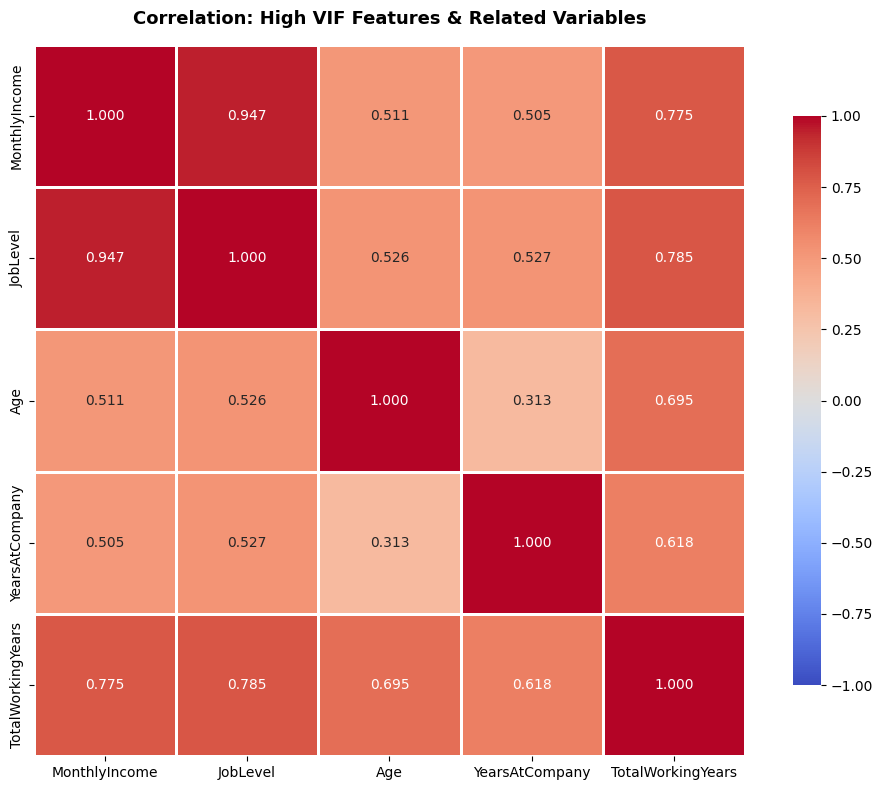


📌 Key Findings:
   • 2 feature(s) with VIF > 10 detected
   • Features: JobLevel, MonthlyIncome

✓ Regularization will help manage this multicollinearity
   - L2 (Ridge): Shrinks correlated coefficients together
   - L1 (Lasso): May select one and drop the other


In [81]:
# Examine correlation between high VIF features
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()

if len(high_vif_features) > 0:
    print(f"\n🔍 Examining correlation between high VIF features:")
    
    # Add related features that might be correlated
    related_features = high_vif_features + ['TotalWorkingYears', 'YearsAtCompany', 'Age']
    related_features = [f for f in related_features if f in X_train.columns]
    related_features = list(set(related_features))  # Remove duplicates
    
    # Calculate correlation matrix for these features
    corr_matrix = X_train[related_features].corr()
    
    print(f"\nCorrelation Matrix for High VIF and Related Features:")
    print("="*70)
    print(corr_matrix.round(3))
    
    # Visualize correlation
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={'shrink': 0.8},
                vmin=-1, vmax=1, ax=ax)
    ax.set_title('Correlation: High VIF Features & Related Variables', 
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    print("\n📌 Key Findings:")
    print(f"   • {len(high_vif_features)} feature(s) with VIF > 10 detected")
    print(f"   • Features: {', '.join(high_vif_features)}")
    print(f"\n✓ Regularization will help manage this multicollinearity")
    print(f"   - L2 (Ridge): Shrinks correlated coefficients together")
    print(f"   - L1 (Lasso): May select one and drop the other")
else:
    print("\n✓ No high VIF features to examine")

## 4. Baseline Model with Regularization (No Privacy)

Train Logistic Regression models with different regularization techniques:  
- **L2 (Ridge)**: Default regularization, shrinks coefficients  

- **L1 (Lasso)**: Performs feature selection by zeroing out coefficients  Use cross-validation to find optimal hyperparameters. This will serve as the **accuracy ceiling** to compare against privatized versions.

- **ElasticNet**: Combines L1 and L2 regularization  

In [82]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, make_scorer
import warnings
warnings.filterwarnings('ignore')

# Define regularization approaches to test
regularization_models = {
    'L2 (Ridge)': {'penalty': 'l2', 'solver': 'lbfgs'},
    'L1 (Lasso)': {'penalty': 'l1', 'solver': 'liblinear'},
    'ElasticNet': {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5}
}

# Range of regularization strengths (C = 1/λ, smaller C = stronger regularization)
C_values = [0.01, 0.1, 1, 10, 100, 1000, 10000]

print("=== Testing Regularization Approaches with Cross-Validation ===")
print("\nNote: C is the inverse of regularization strength (smaller C = stronger regularization)\n")

results = {}
for name, params in regularization_models.items():
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print(f"{'='*60}")
    
    # Set up parameter grid
    param_grid = {'C': C_values}
    
    # Create model
    model = LogisticRegression(max_iter=2000, random_state=42, **params)
    
    # Grid search with cross-validation
    grid_search = GridSearchCV(
        model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)
    
    # Store best model
    best_model = grid_search.best_estimator_
    results[name] = {
        'model': best_model,
        'best_C': grid_search.best_params_['C'],
        'cv_score': grid_search.best_score_
    }
    
    # Evaluate on test set
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    
    print(f"Best C: {grid_search.best_params_['C']}")
    print(f"CV ROC-AUC: {grid_search.best_score_:.4f}")
    print(f"Test ROC-AUC: {test_auc:.4f}")
    
    results[name]['test_auc'] = test_auc
    results[name]['y_pred'] = y_pred
    results[name]['y_prob'] = y_prob

# Select best model based on test AUC
print(f"\n\n{'='*60}")
print("SUMMARY: Regularization Comparison")
print(f"{'='*60}")
for name, res in results.items():
    print(f"{name:15} | Best C: {res['best_C']:6} | CV AUC: {res['cv_score']:.4f} | Test AUC: {res['test_auc']:.4f}")

best_reg_name = max(results.items(), key=lambda x: x[1]['test_auc'])[0]
best_model = results[best_reg_name]['model']

print(f"\n🏆 Best Regularization: {best_reg_name}")
print(f"   Best C: {results[best_reg_name]['best_C']}")
print(f"   Test ROC-AUC: {results[best_reg_name]['test_auc']:.4f}")

# Detailed report for best model
print(f"\n\n{'='*60}")
print(f"Detailed Results for Best Model: {best_reg_name}")
print(f"{'='*60}")
print(classification_report(y_test, results[best_reg_name]['y_pred'], 
                          target_names=['No Attrition', 'Attrition']))

# Store best model as baseline_model for later use
baseline_model = best_model
print(f"\n✓ Baseline model saved: {best_reg_name} with C={results[best_reg_name]['best_C']}")

=== Testing Regularization Approaches with Cross-Validation ===

Note: C is the inverse of regularization strength (smaller C = stronger regularization)


Testing: L2 (Ridge)
Best C: 1
CV ROC-AUC: 0.8068
Test ROC-AUC: 0.8057

Testing: L1 (Lasso)
Best C: 100
CV ROC-AUC: 0.8064
Test ROC-AUC: 0.8055

Testing: ElasticNet
Best C: 100
CV ROC-AUC: 0.8064
Test ROC-AUC: 0.8055


SUMMARY: Regularization Comparison
L2 (Ridge)      | Best C:      1 | CV AUC: 0.8068 | Test AUC: 0.8057
L1 (Lasso)      | Best C:    100 | CV AUC: 0.8064 | Test AUC: 0.8055
ElasticNet      | Best C:    100 | CV AUC: 0.8064 | Test AUC: 0.8055

🏆 Best Regularization: L2 (Ridge)
   Best C: 1
   Test ROC-AUC: 0.8057


Detailed Results for Best Model: L2 (Ridge)
              precision    recall  f1-score   support

No Attrition       0.89      0.97      0.93       247
   Attrition       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71      

In [84]:
# Display detailed logistic regression model summary
print("="*80)
print("LOGISTIC REGRESSION MODEL SUMMARY")
print("="*80)

# Model parameters
print(f"\n📋 Model Configuration:")
print(f"   Model Type: Logistic Regression")
print(f"   Regularization: {best_reg_name}")
print(f"   Regularization Strength (C): {results[best_reg_name]['best_C']}")
print(f"   Solver: {baseline_model.solver}")
print(f"   Max Iterations: {baseline_model.max_iter}")

# Performance metrics
print(f"\n📊 Performance Metrics:")
print(f"   Cross-Validation ROC-AUC: {results[best_reg_name]['cv_score']:.4f}")
print(f"   Test Set ROC-AUC: {results[best_reg_name]['test_auc']:.4f}")
print(f"   Training Samples: {len(y_train)}")
print(f"   Test Samples: {len(y_test)}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred_best = results[best_reg_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)

print(f"\n📈 Additional Metrics:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_best):.4f}")

print(f"\n🔢 Confusion Matrix:")
print(f"                    Predicted")
print(f"                 No      Yes")
print(f"   Actual No   {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"   Actual Yes  {cm[1,0]:4d}    {cm[1,1]:4d}")

# Feature coefficients
coefficients = baseline_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\n🎯 Top 15 Most Important Features (by |Coefficient|):")
print("="*80)
print(f"{'Rank':<6} {'Feature':<30} {'Coefficient':>12} {'Impact':>15}")
print("-"*80)
for idx, row in feature_importance.head(15).iterrows():
    impact = "↑ Increases" if row['Coefficient'] > 0 else "↓ Decreases"
    print(f"{feature_importance.index.get_loc(idx)+1:<6} {row['Feature']:<30} {row['Coefficient']:>12.6f} {impact:>15}")

print(f"\n💡 Intercept: {baseline_model.intercept_[0]:.6f}")

# Count non-zero coefficients (useful for L1/ElasticNet)
non_zero_coef = np.sum(np.abs(coefficients) > 1e-10)
print(f"\n📌 Non-zero coefficients: {non_zero_coef} out of {len(coefficients)} features")
print("="*80)

LOGISTIC REGRESSION MODEL SUMMARY

📋 Model Configuration:
   Model Type: Logistic Regression
   Regularization: L2 (Ridge)
   Regularization Strength (C): 1
   Solver: lbfgs
   Max Iterations: 2000

📊 Performance Metrics:
   Cross-Validation ROC-AUC: 0.8068
   Test Set ROC-AUC: 0.8057
   Training Samples: 1176
   Test Samples: 294

📈 Additional Metrics:
   Accuracy: 0.8741
   Precision: 0.6923
   Recall: 0.3830
   F1-Score: 0.4932

🔢 Confusion Matrix:
                    Predicted
                 No      Yes
   Actual No    239       8
   Actual Yes    29      18

🎯 Top 15 Most Important Features (by |Coefficient|):
Rank   Feature                         Coefficient          Impact
--------------------------------------------------------------------------------
1      OverTime                           0.781960     ↑ Increases
2      YearsSinceLastPromotion            0.481185     ↑ Increases
3      Department                         0.471278     ↑ Increases
4      NumCompaniesWorked 

In [83]:
# Test: What happens with NO regularization?
print("=" * 60)
print("Testing with NO REGULARIZATION (C=1e10)")
print("=" * 60)

no_reg_model = LogisticRegression(C=1e10, max_iter=2000, random_state=42, solver='lbfgs')
no_reg_model.fit(X_train_scaled, y_train)

y_pred_noreg = no_reg_model.predict(X_test_scaled)
y_prob_noreg = no_reg_model.predict_proba(X_test_scaled)[:, 1]
auc_noreg = roc_auc_score(y_test, y_prob_noreg)

print(f"\nTest ROC-AUC: {auc_noreg:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_noreg, 
                          target_names=['No Attrition', 'Attrition']))

print(f"\nComparison:")
print(f"  No Regularization (C=1e10): AUC = {auc_noreg:.4f}")
print(f"  Best Regularized ({best_reg_name}, C={results[best_reg_name]['best_C']}): AUC = {results[best_reg_name]['test_auc']:.4f}")

Testing with NO REGULARIZATION (C=1e10)

Test ROC-AUC: 0.8055

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.89      0.97      0.93       247
   Attrition       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294


Comparison:
  No Regularization (C=1e10): AUC = 0.8055
  Best Regularized (L2 (Ridge), C=1): AUC = 0.8057


---
## Next Steps

- **Section 5:** Apply Differential Privacy using `diffprivlib` at ε = 0.1, 1.0, 10.0
- **Section 6:** Compare utility (accuracy/AUC) across epsilon levels
- **Section 7:** Membership Inference Attack
- **Section 8:** Attribute Inference Attack